In [ ]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [3]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [4]:
well_fit_train = np.load('files/losses/well_fit/asassn_clump_train_loss8-16-32.npy')
dftrainwell = pd.DataFrame(data=np.float_(well_fit_train[1:]), index=np.arange(len(well_fit_train)-1), columns=['loss'])

In [5]:
well_fit_val = np.load('files/losses/well_fit/asassn_clump_val_loss8-16-32.npy')
dfvalwell = pd.DataFrame(data=np.float_(well_fit_val[1:]), index=np.arange(len(well_fit_val)-1), columns=['loss'])

In [6]:
over_fit_train = np.load('files/losses/over_fit/asassn_clump_train_loss_64-128-256.npy')
dftrainover = pd.DataFrame(data=np.float_(over_fit_train[1:]), index=np.arange(len(over_fit_train)-1), columns=['loss'])

In [7]:
overfit_val = np.load('files/losses/over_fit/asassn_clump_val_loss_64-128-256.npy')
dfvalover = pd.DataFrame(data=np.float_(overfit_val[1:]), index=np.arange(len(overfit_val)-1), columns=['loss'])

In [23]:
def learning_curve_plt(dftrain, dfval, network): # Plot learning curve
    epoch = 1 + np.arange(len(dftrain))
    fig, ax = plt.subplots(1, 1, figsize=(10, 5), layout='constrained')
    ax.plot(epoch, dftrain['loss'].to_list(), rasterized=True, linewidth=5)
    ax.plot(epoch, dfval['loss'].to_list(), alpha=0.5, rasterized=True, linewidth=5)
    ax.set_xlabel("Epoch", weight='bold')
    ax.set_ylabel("Loss", weight='bold')
    plt.legend(["Training", "Validation"])
    plt.tight_layout()
    plt.savefig(f'lossplot_{network}.pdf')
    plt.show()

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_8881/909477555.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


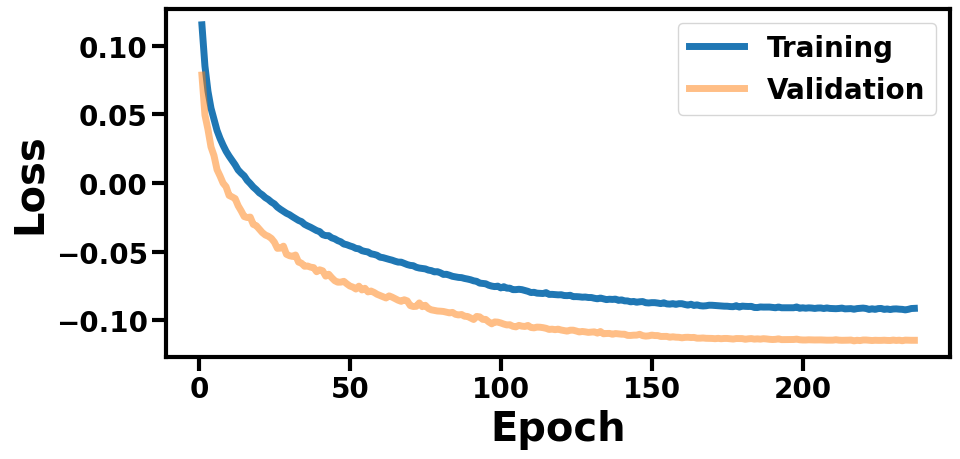

In [24]:
learning_curve_plt(dftrainwell, dfvalwell, '8-16-32')

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_8881/909477555.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


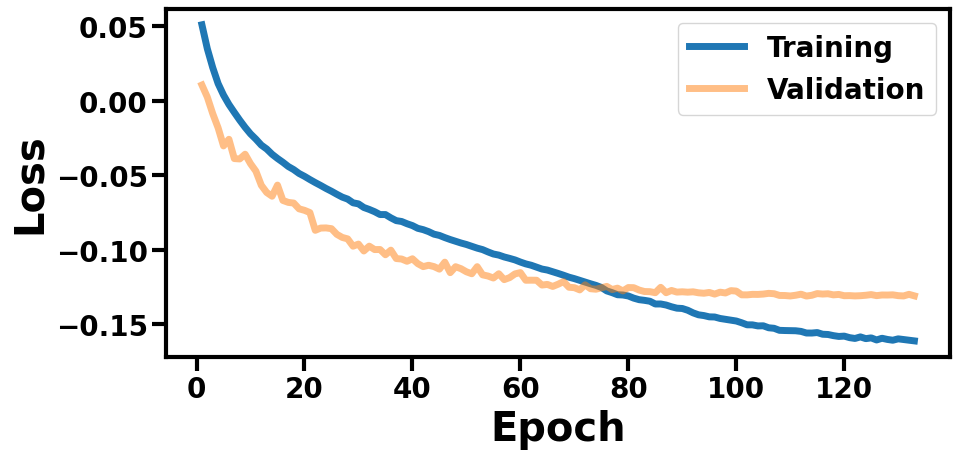

In [25]:
learning_curve_plt(dftrainover, dfvalover, '64-128-256')